# Loan Default Prediction - Capstone Project

Welcome! In this notebook, we will build a complete Machine Learning pipeline for Loan Default Prediction. This notebook covers:
1. Data Loading
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Handling Imbalanced Data (SMOTE)
5. Model Training & Evaluation
6. Saving the Best Model

## 1. Import Libraries
First, let's import all the necessary libraries.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

# Ignore warnings for clean output
warnings.filterwarnings('ignore')

# Adjust matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')

## 2. Load Dataset
We load our dataset from the `data` folder. (Note: Make sure to place your `loan_data.csv` inside the `data/` folder).

In [5]:
# Load the data
df = pd.read_csv(r"C:\Users\ojasp\ML codes\CAPSTONE PROJECT #1\loan-default-mlops\data\Loan_Default.csv")

print("Shape of dataset:", df.shape)
display(df.head())


Shape of dataset: (148670, 34)


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


### Dataset Information

In [6]:
df.info()
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

## 3. Data Cleaning
Let's import our custom preprocessing functions from the `src/preprocessing.py` file to handle missing values and outliers.

In [7]:
import sys
sys.path.append('../')
from src.preprocessing import handle_missing_values, remove_outliers_iqr

# 1. Drop duplicates
df = df.drop_duplicates()

# 2. Handle missing values
df_clean = handle_missing_values(df)
print("Missing values after cleaning:\n", df_clean.isnull().sum())

# 3. Remove outliers (applying only to numerical columns)
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.drop('Status', errors='ignore')
df_clean = remove_outliers_iqr(df_clean, numerical_cols)
print("\nShape after outlier removal:", df_clean.shape)

Missing values after cleaning:
 ID                           0
year                         0
loan_limit                   0
Gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
Credit_Worthiness            0
open_credit                  0
business_or_commercial       0
loan_amount                  0
rate_of_interest             0
Interest_rate_spread         0
Upfront_charges              0
term                         0
Neg_ammortization            0
interest_only                0
lump_sum_payment             0
property_value               0
construction_type            0
occupancy_type               0
Secured_by                   0
total_units                  0
income                       0
credit_type                  0
Credit_Score                 0
co-applicant_credit_type     0
age                          0
submission_of_application    0
LTV                          0
Region                       0
Securit

## 4. Exploratory Data Analysis (EDA)
Let's visualize the data to understand distributions and correlations.

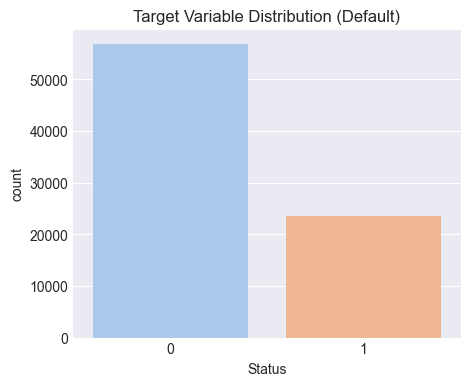

Insight: We can see the class distribution. If there are far more 0s than 1s, we have an imbalanced dataset.


In [9]:
# Target Variable Distribution
plt.figure(figsize=(5, 4))
sns.countplot(data=df_clean, x='Status', palette='pastel')
plt.title("Target Variable Distribution (Default)")
plt.show()

print("Insight: We can see the class distribution. If there are far more 0s than 1s, we have an imbalanced dataset.")

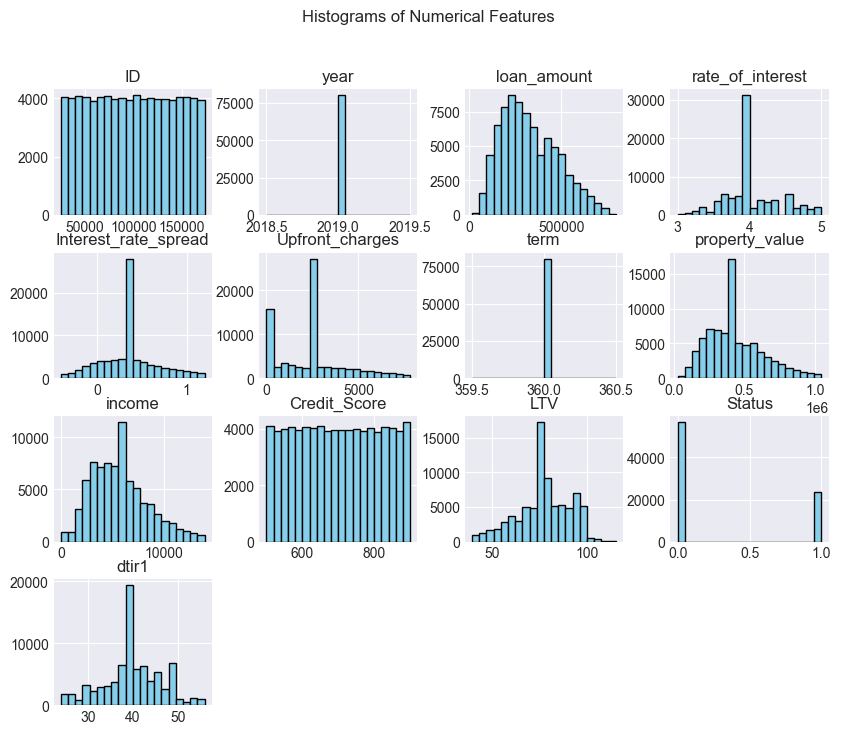

Insight: These histograms help us understand the distribution (normal, skewed, etc.) of each numerical feature.


In [10]:
# Numerical Features Histogram
df_clean[numerical_cols].hist(bins=20, figsize=(10, 8), color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Numerical Features')
plt.show()

print("Insight: These histograms help us understand the distribution (normal, skewed, etc.) of each numerical feature.")

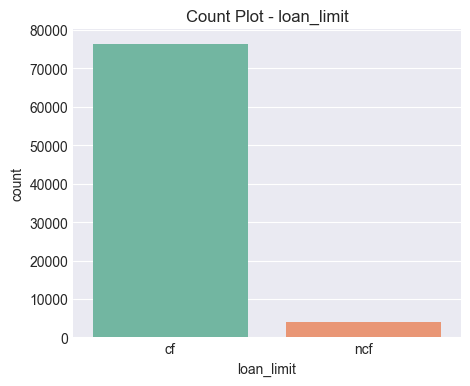

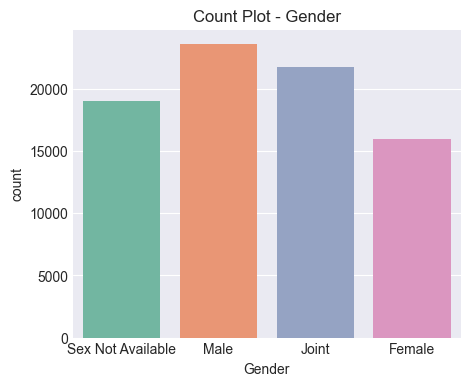

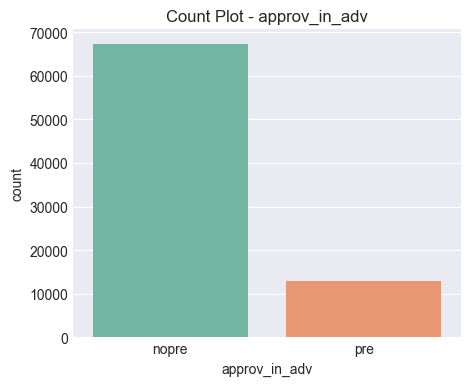

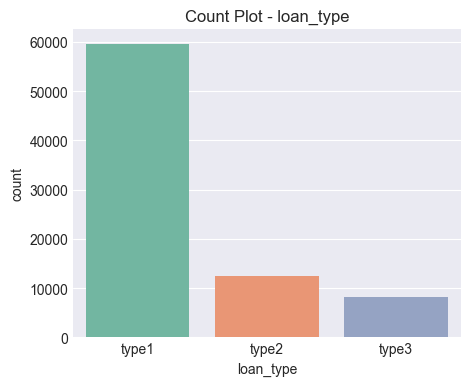

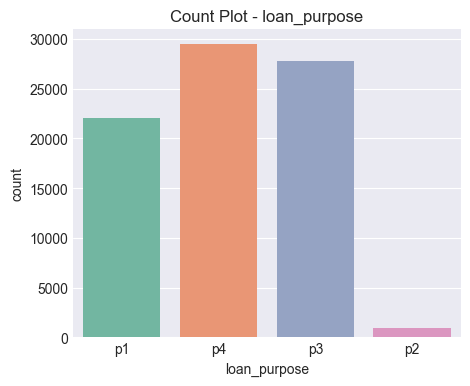

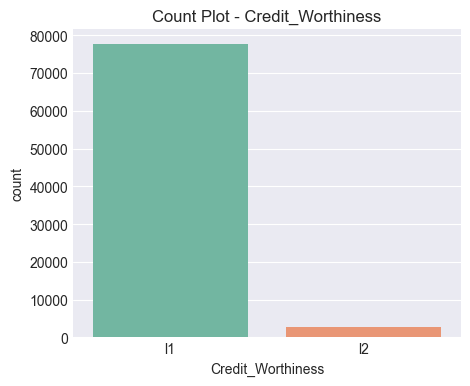

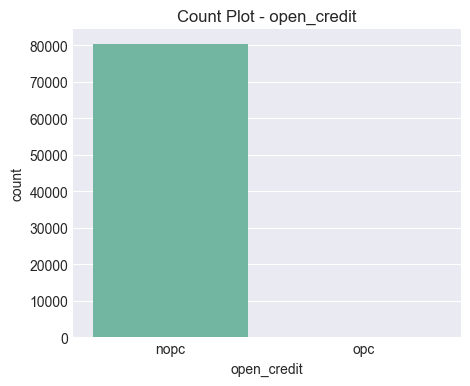

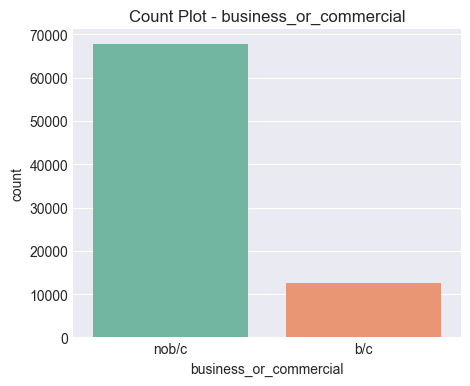

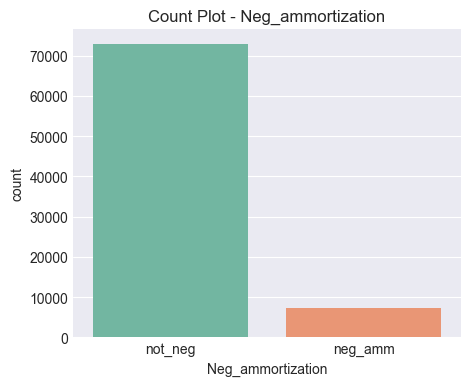

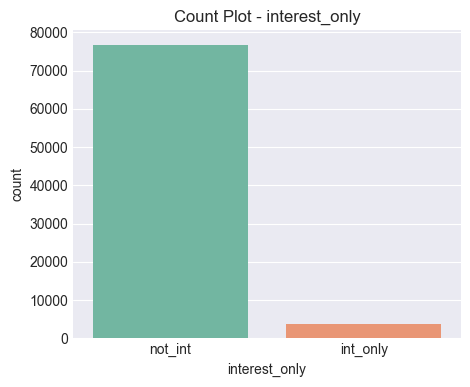

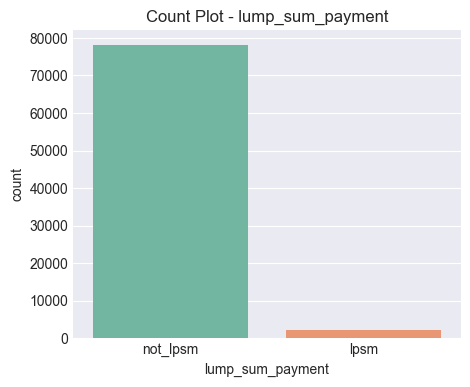

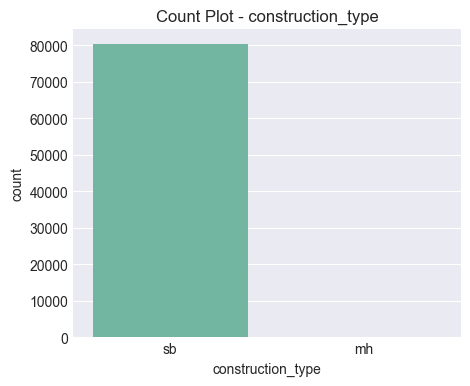

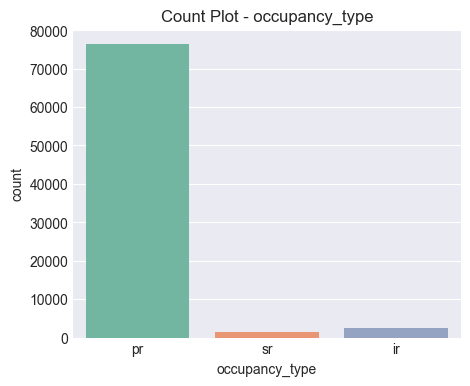

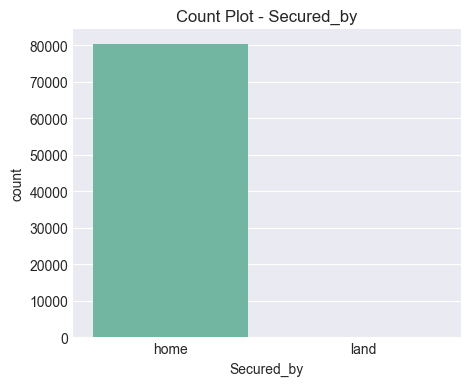

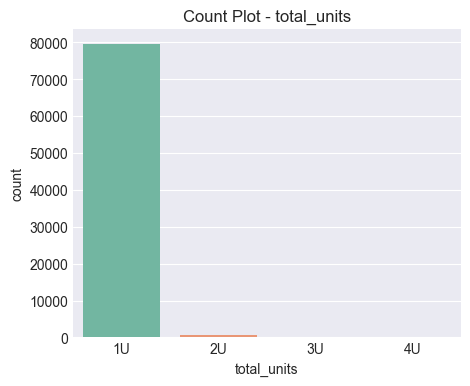

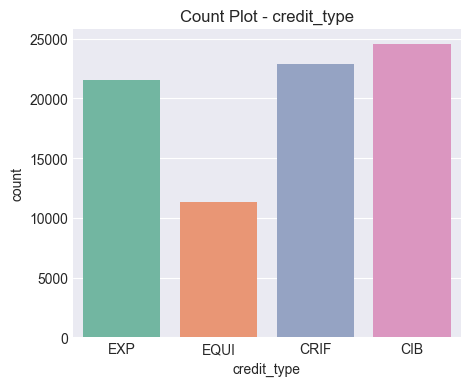

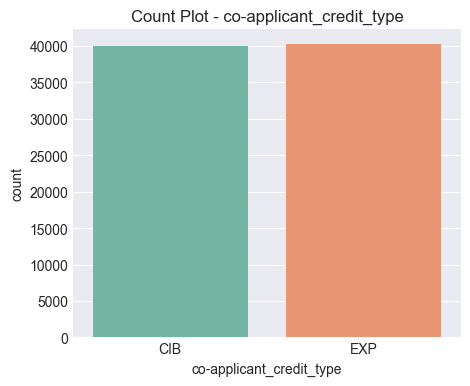

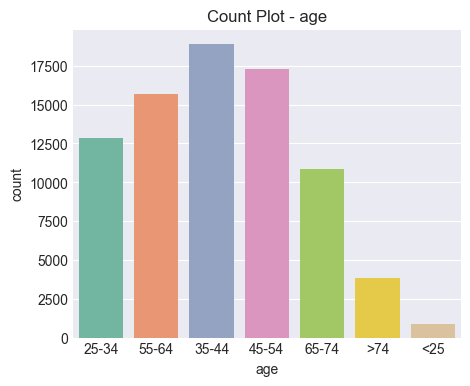

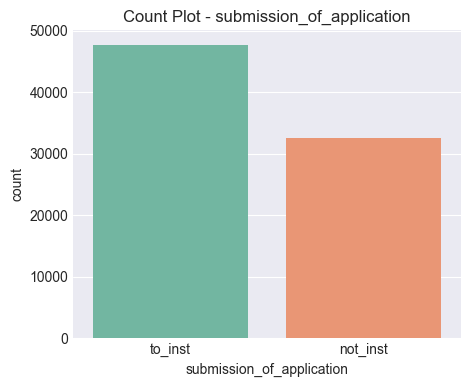

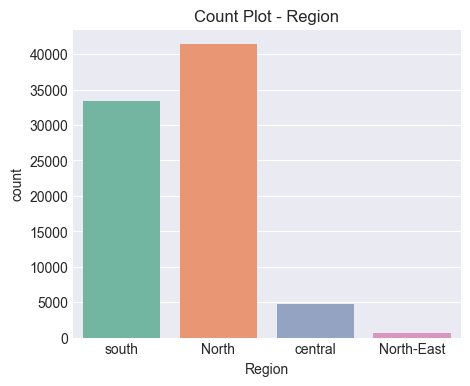

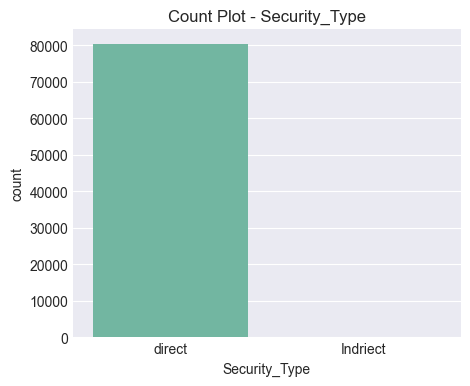

Insight: Visualize the frequencies of different categories in our dataset.


In [11]:
# Count Plot for Categorical columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns
for col in categorical_cols:
    plt.figure(figsize=(5, 4))
    sns.countplot(data=df_clean, x=col, palette='Set2')
    plt.title(f"Count Plot - {col}")
    plt.show()
print("Insight: Visualize the frequencies of different categories in our dataset.")

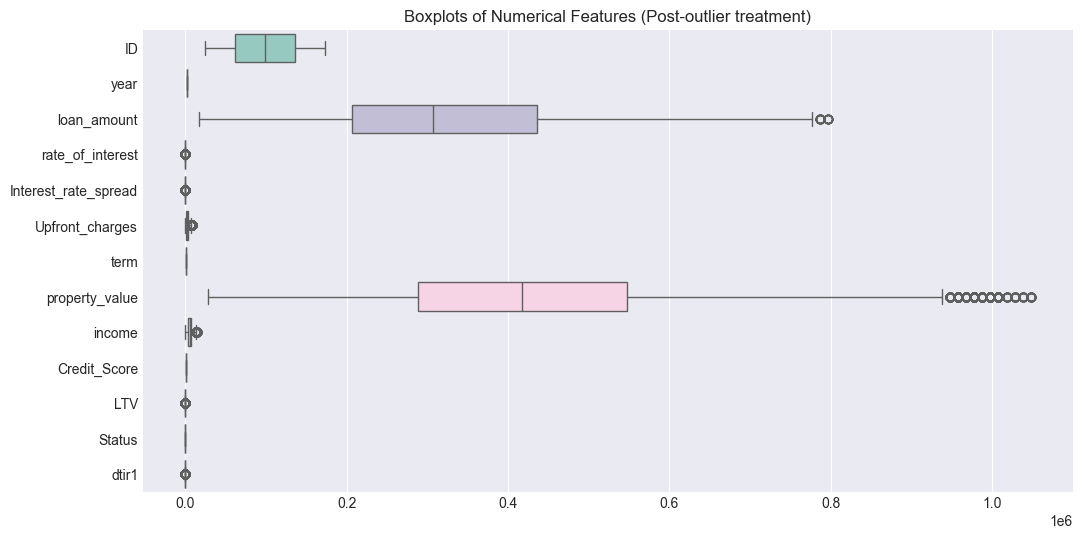

Insight: Helps to visually verify that severe outliers were handled appropriately.


In [12]:
# Boxplots for Outlier Analysis
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean[numerical_cols], orient='h', palette='Set3')
plt.title("Boxplots of Numerical Features (Post-outlier treatment)")
plt.show()
print("Insight: Helps to visually verify that severe outliers were handled appropriately.")

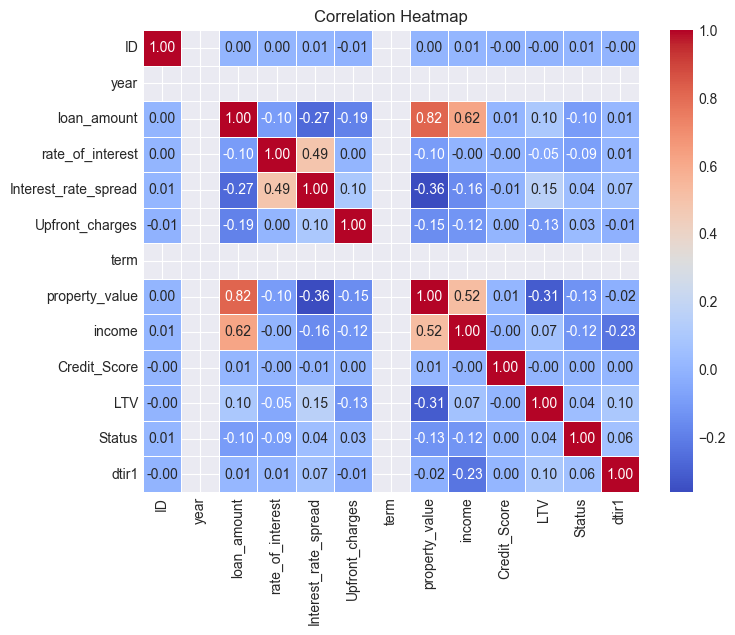

Insight: Checks for multicollinearity. Highly correlated features might need to be dropped.


In [13]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = df_clean[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

print("Insight: Checks for multicollinearity. Highly correlated features might need to be dropped.")

## 5. Data Preprocessing
Encode categorical features, split the data, and scale numerical features.

In [14]:
from src.preprocessing import encode_categorical_features, scale_features
from sklearn.model_selection import train_test_split
from src.config import RANDOM_STATE, TEST_SIZE

# 1. Encoding
df_encoded = encode_categorical_features(df_clean)

# 2. Train-Test Split
X = df_encoded.drop('Status', axis=1)
y = df_encoded['Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")

# 3. Scaling
# Store column names to recreate DataFrame after scaling
columns = X_train.columns
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

# Convert back to DataFrame for easier handling
X_train = pd.DataFrame(X_train_scaled, columns=columns)
X_test = pd.DataFrame(X_test_scaled, columns=columns)


Training set shape: (64240, 33), Test set shape: (16060, 33)


## 6. Handle Class Imbalance
We use SMOTE (Synthetic Minority Over-sampling Technique) to generate synthetic samples for the minority class. This prevents our model from becoming biased towards the majority class.

In [15]:
from src.preprocessing import apply_smote

print("Before SMOTE - y_train counts:\n", y_train.value_counts())
X_train_resampled, y_train_resampled = apply_smote(X_train, y_train, random_state=RANDOM_STATE)
print("\nAfter SMOTE - y_train counts:\n", y_train_resampled.value_counts())

Before SMOTE - y_train counts:
 Status
0    45423
1    18817
Name: count, dtype: int64

After SMOTE - y_train counts:
 Status
0    45423
1    45423
Name: count, dtype: int64


## 7. Train Multiple Models & 8. Hyperparameter Tuning & 9. Evaluation
We will iterate through multiple models, perform hyperparameter tuning using GridSearchCV where applicable, and evaluate their performance.


--- Training Logistic Regression ---
Metrics: {'Accuracy': 0.7036737235367372, 'Precision': 0.49586901006459366, 'Recall': 0.7017431972789115, 'F1-Score': 0.5811108177097086, 'ROC-AUC': 0.7685446746063695, 'Model': 'Logistic Regression'}


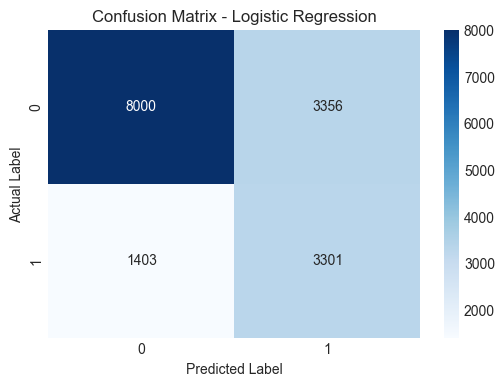

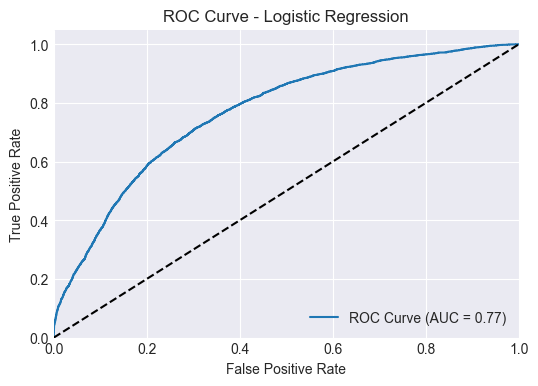


--- Training Decision Tree ---
Tuning hyperparameters for Decision Tree...
Metrics: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1-Score': 1.0, 'ROC-AUC': 1.0, 'Model': 'Decision Tree'}


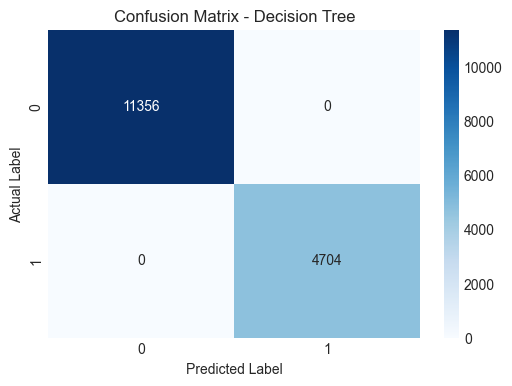

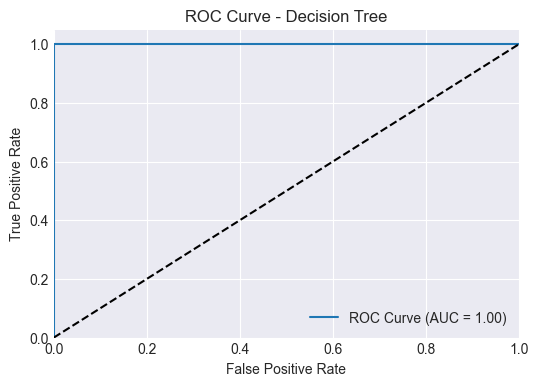


--- Training Random Forest ---
Tuning hyperparameters for Random Forest...
Metrics: {'Accuracy': 0.9998754669987546, 'Precision': 0.9995750106247344, 'Recall': 1.0, 'F1-Score': 0.999787460148778, 'ROC-AUC': 1.0, 'Model': 'Random Forest'}


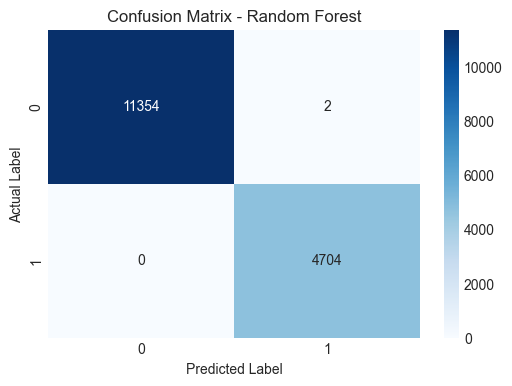

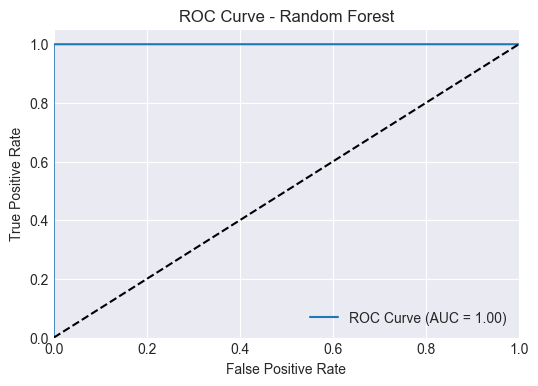


--- Training Naive Bayes ---
Metrics: {'Accuracy': 0.7356164383561644, 'Precision': 1.0, 'Recall': 0.09736394557823129, 'F1-Score': 0.17745060054242542, 'ROC-AUC': 0.9998934922022702, 'Model': 'Naive Bayes'}


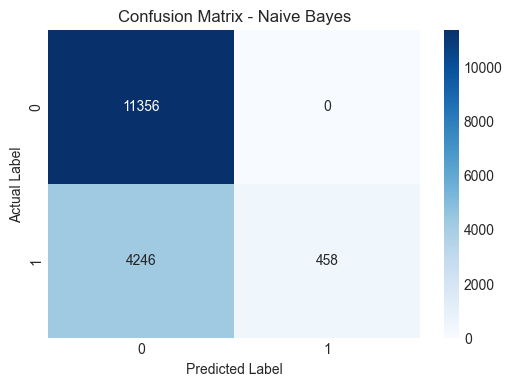

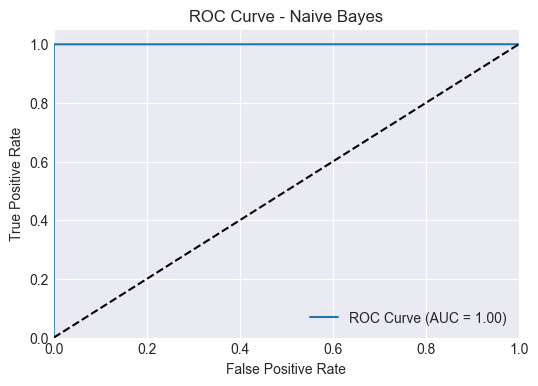


--- Training KNN ---
Tuning hyperparameters for KNN...
Metrics: {'Accuracy': 0.8744084682440847, 'Precision': 0.7219560548488353, 'Recall': 0.9289965986394558, 'F1-Score': 0.8124941898298782, 'ROC-AUC': 0.9386672708005358, 'Model': 'KNN'}


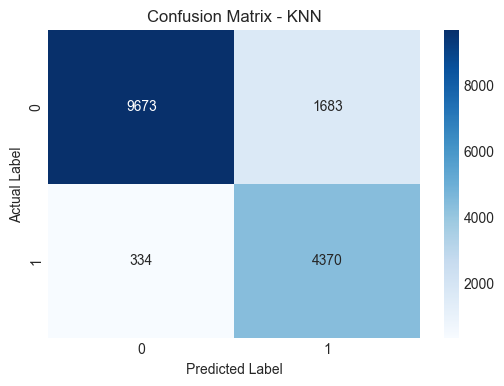

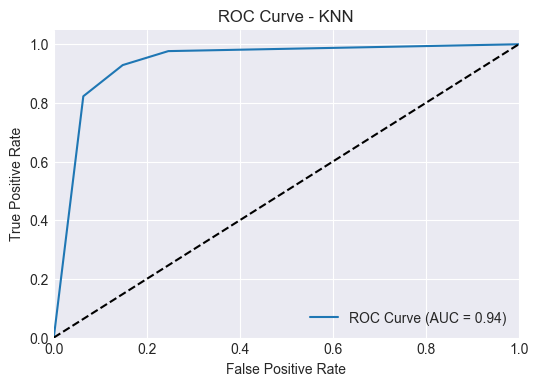

In [16]:
from src.train_utils import get_models, tune_hyperparameters
from src.evaluate import evaluate_model, plot_confusion_matrix, plot_roc_curve
from src.config import PARAM_GRIDS

models = get_models(random_state=RANDOM_STATE)
results = []
best_model_obj = None
best_f1 = 0
best_model_name = ""

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    
    # Hyperparameter tuning if params exist
    if name in PARAM_GRIDS:
        print(f"Tuning hyperparameters for {name}...")
        model = tune_hyperparameters(model, PARAM_GRIDS[name], X_train_resampled, y_train_resampled)
    else:
        model.fit(X_train_resampled, y_train_resampled)
        
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Evaluation
    metrics = evaluate_model(y_test, y_pred, y_prob)
    metrics['Model'] = name
    results.append(metrics)
    
    print(f"Metrics: {metrics}")
    
    # Plotting
    plot_confusion_matrix(y_test, y_pred, name)
    if y_prob is not None:
        plot_roc_curve(y_test, y_prob, name)
        
    # Keep track of the best model (using F1-Score)
    if metrics['F1-Score'] > best_f1:
        best_f1 = metrics['F1-Score']
        best_model_obj = model
        best_model_name = name

### Models Comparison

In [17]:
results_df = pd.DataFrame(results).set_index('Model')
display(results_df.sort_values(by='F1-Score', ascending=False))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000
Random Forest,0.999875,0.999575,1.000000,0.999787,1.000000
KNN,0.874408,0.721956,0.928997,0.812494,0.938667
Logistic Regression,0.703674,0.495869,0.701743,0.581111,0.768545
Naive Bayes,0.735616,1.000000,0.097364,0.177451,0.999893


## 10. Feature Importance
For Tree-based models, let's visualize which features are most important.

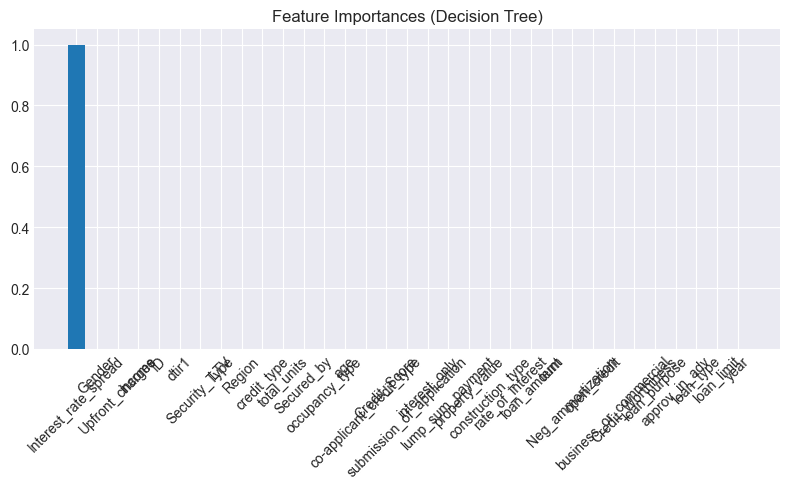

Insight: These are the top features influencing whether a person defaults on a loan.


In [18]:
if hasattr(best_model_obj, 'feature_importances_'):
    importances = best_model_obj.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(8, 5))
    plt.title(f"Feature Importances ({best_model_name})")
    plt.bar(range(X_train.shape[1]), importances[indices], align="center")
    plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=45)
    plt.tight_layout()
    plt.show()
    print("Insight: These are the top features influencing whether a person defaults on a loan.")
else:
    print(f"{best_model_name} does not support feature_importances_.")

## 11. Save Best Model
We save the best model to the `models/` directory so our FastAPI application can load it.

In [19]:
import os
from src.train_utils import save_model

# Ensure models directory exists
os.makedirs('../models', exist_ok=True)

model_path = '../models/best_model.pkl'
save_model(best_model_obj, model_path)

print(f"Best model ({best_model_name}) saved successfully!")

# Test reloading the model
loaded_model = joblib.load(model_path)
sample_pred = loaded_model.predict(X_test.iloc[[0]])
print(f"Sample prediction from loaded model: {'Default' if sample_pred[0] == 1 else 'No Default'}")

Model saved successfully at: ../models/best_model.pkl
Best model (Decision Tree) saved successfully!
Sample prediction from loaded model: No Default
